# Advanced Workbook DLMDSAS01 — computations

This notebook produces **every number and every figure** that appears in the
workbook. It is the only place where a result is calculated; the prose in
`src/*.md` contains no literal numeric result, only `{{task.key}}` tokens that
`render.py` fills in from the `build/results.json` file written by the last
cell here. Text and computation therefore cannot drift apart.

Each task follows the same shape: derive the quantity in closed form where one
exists, evaluate it numerically, and cross-check the two against each other.
Those cross-checks are what the "Trust" paragraph of each task reports.

**How to run.** Either open this notebook and choose *Run All*, or run it
headlessly with `./build.sh`, which executes it with `run_notebook.py` before
rendering the document. Both routes write the same `build/results.json`.

**Contents**

| Section | Subject |
|---|---|
| Setup | imports, figure style, shared helpers |
| Parameters | the personal values and the signature check |
| Task 1 | Bernoulli vote |
| Task 2 | waiting time for the owl |
| Task 3 | bandwidth to failure of a pair of routers |
| Task 4 | hypothesis test on hammer weights |
| Task 5 | OLS and ridge on a degree-10 polynomial |
| Task 6 | Bayesian estimate of a gamma rate |
| Output | assemble and write `build/results.json` |

## Setup

The figure style is fixed once here so that all seven figures share it: a
sans-serif face at 9 pt, restrained colours, no top or right spine, and a
resolution high enough to stay legible when the PNG is placed at 15.5 cm in
the document. `FIGSIZE` is 6.3 inches wide, which is 16 cm, and so fits the
17 cm text block that A4 with 2 cm margins leaves.

In [1]:
%matplotlib inline

import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize, special, stats

# The notebook has no __file__, so locate the project directory by looking for
# params.py, starting at the working directory and walking upwards. This keeps
# the notebook runnable from Jupyter, from Cursor and from run_notebook.py.
HERE = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "params.py").exists())
FIGDIR = HERE / "figures"
BUILDDIR = HERE / "build"

# Sober academic figure style: sans-serif, restrained colours, print-legible.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    # Stated rather than inherited: the inline backend defaults to a
    # transparent canvas, which would put transparent PNGs in the document.
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

INK = "#1a1a1a"
ACCENT = "#1a5ca8"
ALT = "#c42848"
MUTED = "#8a8a8a"

#: 16 cm wide at the mandated 2 cm margins leaves a 17 cm text block.
FIGSIZE = (6.3, 3.4)

#: Filled in task by task; the final cell flattens and writes it out.
results: dict = {}

print(f"project directory: {HERE}")

project directory: /Users/elena/Desktop/Workspace/advanced_statistics/deliverables/workbook


### Shared helpers

Three small utilities used across the tasks. `matvec` exists only to work
around a platform warning and is explained in its docstring; `save_figure`
writes a PNG into `figures/` and returns the file name that the prose will
reference; `flatten` turns the nested results into the dotted keys that
`render.py` looks up.

In [2]:
def matvec(matrix: np.ndarray, vector: np.ndarray) -> np.ndarray:
    """Matrix-vector product guarded against a spurious BLAS warning.

    NumPy 2.0 built against Apple's Accelerate framework raises divide-by-zero,
    overflow and invalid warnings from ``matmul`` even when every input and
    every output is finite; the vectorised kernel evaluates masked lanes and
    reports their flags. The products here were checked against ``einsum`` and
    agree to 2e-16, so the warning is suppressed for this call only and the
    result is verified rather than trusted blindly.
    """
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        out = matrix @ vector
    if not np.isfinite(out).all():
        raise FloatingPointError("non-finite value in matrix-vector product")
    return out


def save_figure(fig, name: str) -> str:
    """Write ``figures/<name>.png`` and return the file name.

    The figure is deliberately left open so that the inline backend also shows
    it underneath the cell; the document uses the file, the reader uses the
    inline copy, and both come from the same call.
    """
    FIGDIR.mkdir(parents=True, exist_ok=True)
    path = FIGDIR / f"{name}.png"
    fig.savefig(path)
    return path.name


def flatten(nested: dict) -> dict:
    """Turn ``{"task1": {"p": 0.65}}`` into ``{"task1.p": 0.65}``."""
    flat = {}
    for section, values in nested.items():
        for key, value in values.items():
            flat[f"{section}.{key}"] = value
    return flat

## Parameters

`params.py` is the single source of truth for the personal values. It parses
`exam_tasks/assignment_values_2.txt`, so no number is ever retyped by hand,
and it refuses to import if the signature in that file is not the one this
workbook was written against. That check is what makes it impossible to build
the document against a mixed or regenerated parameter set by accident.

It stays a separate module rather than a cell because it is file parsing
rather than statistics, and because `render.py` also lists it in Appendix B.

In [3]:
import params as P

print(f"signature      {P.SIGNATURE}")
print("branches       " + ", ".join(f"task {k}: xi = {v:g}"
                                    for k, v in P.BRANCHES.items()))
print(f"xi5 + xi7      {P.XI5 + P.XI7:.2f}  ->  renormalised to "
      f"{P.XI5_STAR:.6f} + {P.XI7_STAR:.6f} = {P.XI5_STAR + P.XI7_STAR:.0f}")

signature      99d9e51eff0fb88f6911fa8b4392742591f8f6da
branches       task 1: xi = 0, task 2: xi = 1, task 3: xi = 0, task 4: xi = 2, task 5: xi = 2
xi5 + xi7      0.99  ->  renormalised to 0.666667 + 0.333333 = 1


## Task 1 — Bernoulli vote

A single voter either supports the motion ($x = 1$) with probability
$p = \xi_2$ or opposes it ($x = 0$) with probability $q = 1 - p$. For a
Bernoulli variable the mean is $p$ and the variance is $pq$, so there is
nothing to solve numerically: the cell below evaluates the closed forms and
draws the two-bar probability mass function with $\mathbb{E}[X]$ marked on it.

The mean is drawn as a horizontal line at $100p$ per cent to make the point
the prose makes: the expectation of a Bernoulli variable is the proportion of
the population that votes in favour, not a value the variable can ever take.

E[X] = 0.6500   Var(X) = 0.2275   SD(X) = 0.4770


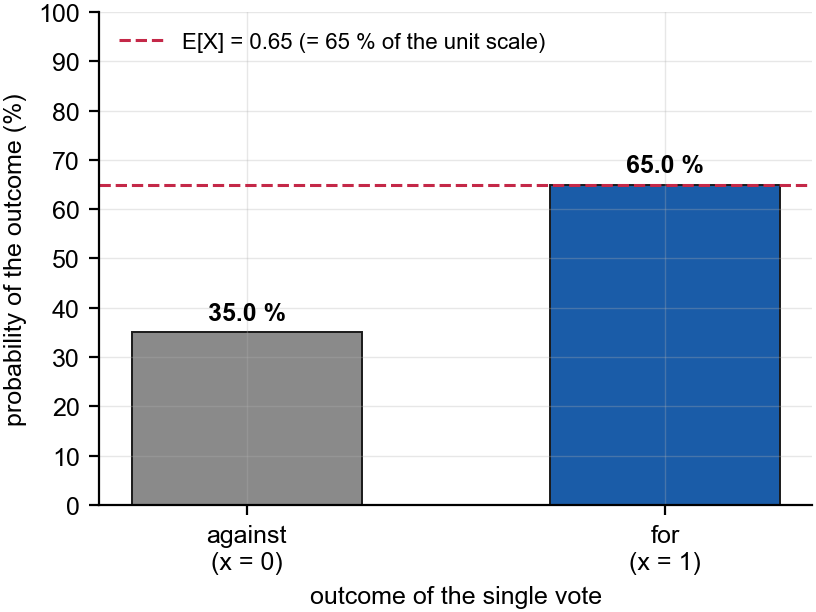

In [4]:
vote_p = P.XI2
vote_q = 1.0 - vote_p
vote_mean = vote_p
vote_var = vote_p * vote_q

fig, ax = plt.subplots(figsize=(4.6, 3.2))
bars = ax.bar(["against\n(x = 0)", "for\n(x = 1)"], [100 * vote_q, 100 * vote_p],
              width=0.55, color=[MUTED, ACCENT], edgecolor=INK, linewidth=0.7)
for bar, value in zip(bars, [100 * vote_q, 100 * vote_p]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.1f} %",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(100 * vote_mean, color=ALT, linestyle="--", linewidth=1.1,
           label=f"E[X] = {vote_mean:.2f} (= {100 * vote_mean:.0f} % of the unit scale)")
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_ylabel("probability of the outcome (%)")
ax.set_xlabel("outcome of the single vote")
ax.legend(loc="upper left", frameon=False, fontsize=8)
vote_fig = save_figure(fig, "task1_bernoulli")

results["task1"] = {
    "p": vote_p, "q": vote_q, "mean": vote_mean, "var": vote_var,
    "sd": math.sqrt(vote_var),
    "p_pct": 100 * vote_p, "q_pct": 100 * vote_q,
    "fig": vote_fig,
}
print(f"E[X] = {vote_mean:.4f}   Var(X) = {vote_var:.4f}   SD(X) = {math.sqrt(vote_var):.4f}")

## Task 2 — waiting time for the owl

The waiting time $Y \ge 0$ until the owl is first heard has survival function

$$\bar F_Y(y) = P(Y > y) = w_1 e^{-a y^2} + w_2 e^{-b y^8}.$$

Each term is the survival function of a Weibull variable: $e^{-a y^2}$ has
shape 2 (a Rayleigh distribution) with scale $a^{-1/2}$, and $e^{-b y^8}$ has
shape 8 with scale $b^{-1/8}$. So $Y$ is a mixture of two Weibull waiting
times, one that decays early and one that switches on late.

**Why the weights are renormalised.** A survival function must satisfy
$\bar F_Y(0) = 1$, which forces $w_1 + w_2 = 1$. The generator truncates
$\xi_5$ and $\xi_7$ to two decimals, so as delivered they sum to 0.99 and
would leave 1 % of the probability mass unassigned. Dividing each by their sum
restores the constraint exactly and changes nothing else about the shape;
`params.py` exposes the corrected weights as `XI5_STAR` and `XI7_STAR`.

The density is minus the derivative of the survival function:

$$f_Y(y) = -\frac{d}{dy}\bar F_Y(y) = 2 a w_1 y e^{-a y^2} + 8 b w_2 y^7 e^{-b y^8}.$$

In [5]:
owl_w1, owl_w2 = P.XI5_STAR, P.XI7_STAR
owl_a, owl_b = P.XI6, P.XI8


def owl_survival(y):
    y = np.asarray(y, dtype=float)
    return owl_w1 * np.exp(-owl_a * y ** 2) + owl_w2 * np.exp(-owl_b * y ** 8)


def owl_density(y):
    y = np.asarray(y, dtype=float)
    return (owl_w1 * 2 * owl_a * y * np.exp(-owl_a * y ** 2)
            + owl_w2 * 8 * owl_b * y ** 7 * np.exp(-owl_b * y ** 8))


print(f"weights   w1 = {owl_w1:.6f}   w2 = {owl_w2:.6f}")
print(f"shapes    a = {owl_a:g}   b = {owl_b:g}")
print(f"Fbar(0)   {float(owl_survival(0.0)):.6f}   (must be exactly 1)")

weights   w1 = 0.666667   w2 = 0.333333
shapes    a = 8   b = 5
Fbar(0)   1.000000   (must be exactly 1)


### Moments, in closed form and numerically

For a non-negative variable the expectation is the area under the survival
function, $\mathbb{E}[Y] = \int_0^\infty \bar F_Y(y)\,dy$, and the second
moment is $\mathbb{E}[Y^2] = 2\int_0^\infty y \bar F_Y(y)\,dy$. Substituting
the two exponentials and integrating term by term gives

$$\mathbb{E}[Y] = \frac{w_1}{2}\sqrt{\frac{\pi}{a}} + w_2 \Gamma(9/8) b^{-1/8},
\qquad
\mathbb{E}[Y^2] = \frac{w_1}{a} + \frac{w_2 \Gamma(1/4)}{4 b^{1/4}} .$$

The same two quantities are then obtained a second time by numerical
quadrature against the density, as an independent check on the algebra. The
total mass $\int_0^\infty f_Y = 1$ is checked at the same time.

In [6]:
owl_mean_exact = (owl_w1 * 0.5 * math.sqrt(math.pi / owl_a)
                  + owl_w2 * special.gamma(9 / 8) * owl_b ** (-1 / 8))
owl_second_exact = owl_w1 / owl_a + owl_w2 * special.gamma(0.25) / (4 * owl_b ** 0.25)
owl_var_exact = owl_second_exact - owl_mean_exact ** 2

owl_mean_num = integrate.quad(lambda y: y * owl_density(y), 0, np.inf)[0]
owl_second_num = integrate.quad(lambda y: y ** 2 * owl_density(y), 0, np.inf)[0]
owl_total_mass = integrate.quad(owl_density, 0, np.inf)[0]

print(f"E[Y]    closed form {owl_mean_exact:.10f}   quadrature {owl_mean_num:.10f}"
      f"   difference {abs(owl_mean_exact - owl_mean_num):.2e}")
print(f"E[Y^2]  closed form {owl_second_exact:.10f}   quadrature {owl_second_num:.10f}")
print(f"total mass {owl_total_mass:.12f}")
print(f"E[Y] = {owl_mean_exact * 60:.2f} min,  SD = {math.sqrt(owl_var_exact) * 60:.2f} min")

E[Y]    closed form 0.4655938988   quadrature 0.4655938988   difference 0.00e+00
E[Y^2]  closed form 0.2853826230   quadrature 0.2853826230
total mass 1.000000000000
E[Y] = 27.94 min,  SD = 15.72 min


### Quartiles, per-minute probabilities and the two components

The quartiles solve $F_Y(y) = 1 - \bar F_Y(y) = q$ for $q \in \{0.25, 0.5, 0.75\}$.
There is no closed form, so each is found by bisection on $[0, 20]$ hours,
which brackets every root because $\bar F_Y$ falls from 1 to essentially 0 well
inside that range.

The per-minute probabilities are exact rather than approximated from the
density: the chance that the owl is first heard during minute $k$ is
$\bar F_Y\!\left(\frac{k-1}{60}\right) - \bar F_Y\!\left(\frac{k}{60}\right)$.

The component means use the Weibull mean $\text{scale} \times \Gamma(1 + 1/\text{shape})$,
and the two modes are located by bounded search on either side of the dip that
separates the early Rayleigh bump from the late shape-8 bump.

In [7]:
owl_quartiles = [optimize.brentq(lambda y: 1 - owl_survival(y) - q, 0, 20)
                 for q in (0.25, 0.5, 0.75)]

owl_comp1_scale, owl_comp2_scale = owl_a ** -0.5, owl_b ** -0.125
owl_comp1_mean = owl_comp1_scale * special.gamma(1 + 1 / 2)
owl_comp2_mean = owl_comp2_scale * special.gamma(1 + 1 / 8)

owl_p_2_4 = float(owl_survival(2.0) - owl_survival(4.0))
owl_p_within_hour = float(1 - owl_survival(1.0))

# Probability that the owl is first heard during minute k.
owl_minutes = np.arange(1, 61)
owl_per_minute = owl_survival((owl_minutes - 1) / 60) - owl_survival(owl_minutes / 60)

owl_mode1 = float(optimize.minimize_scalar(
    lambda y: -owl_density(y), bounds=(0.01, 0.5), method="bounded").x)
owl_mode2 = float(optimize.minimize_scalar(
    lambda y: -owl_density(y), bounds=(0.6, 1.2), method="bounded").x)

print(f"Q1 {owl_quartiles[0] * 60:.2f} min   median {owl_quartiles[1] * 60:.2f} min"
      f"   Q3 {owl_quartiles[2] * 60:.2f} min")
print(f"P(within the hour) = {100 * owl_p_within_hour:.3f} %")
print(f"P(2 h < Y < 4 h)   = {owl_p_2_4:.3e}")
print(f"modes at {owl_mode1 * 60:.2f} min and {owl_mode2 * 60:.2f} min")

Q1 14.54 min   median 24.90 min   Q3 42.79 min
P(within the hour) = 99.753 %
P(2 h < Y < 4 h)   = 8.443e-15
modes at 15.03 min and 47.90 min


### Figure 2 — the density with its quartiles

Plotted on $[0, 1.4]$ hours, which contains essentially all of the mass. The
bimodality is the visible signature of the mixture.

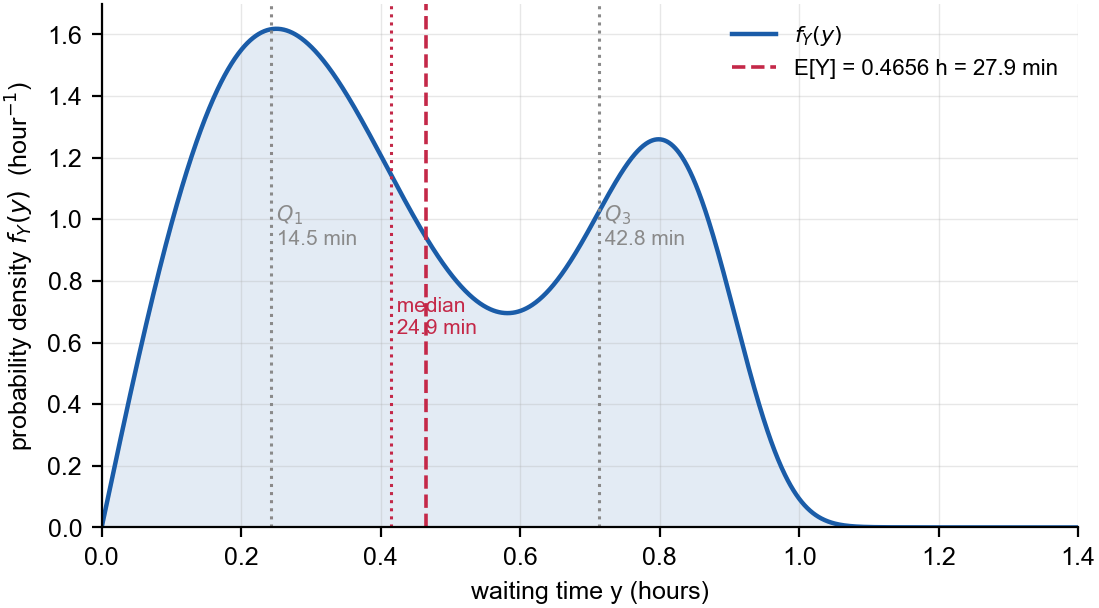

In [8]:
owl_grid = np.linspace(0, 1.4, 1400)
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(owl_grid, owl_density(owl_grid), color=ACCENT, linewidth=1.6,
        label=r"$f_Y(y)$")
ax.fill_between(owl_grid, owl_density(owl_grid), color=ACCENT, alpha=0.12)
owl_top = ax.get_ylim()[1]
for value, label, colour, height in zip(
        owl_quartiles, [r"$Q_1$", "median", r"$Q_3$"],
        [MUTED, ALT, MUTED], [0.62, 0.44, 0.62]):
    ax.axvline(value, color=colour, linestyle=":", linewidth=1.1)
    ax.text(value, owl_top * height, f" {label}\n {value * 60:.1f} min",
            fontsize=7.5, color=colour, va="top")
ax.axvline(owl_mean_exact, color=ALT, linestyle="--", linewidth=1.3,
           label=f"E[Y] = {owl_mean_exact:.4f} h = {owl_mean_exact * 60:.1f} min")
ax.set_xlabel("waiting time y (hours)")
ax.set_ylabel(r"probability density $f_Y(y)$  (hour$^{-1}$)")
ax.set_xlim(0, 1.4)
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", frameon=False, fontsize=8)
owl_fig_pdf = save_figure(fig, "task2_density")

### Figure 3 — the same distribution, minute by minute

The same information as a bar chart over the 60 minutes of the first hour,
which is the form a reader can act on.

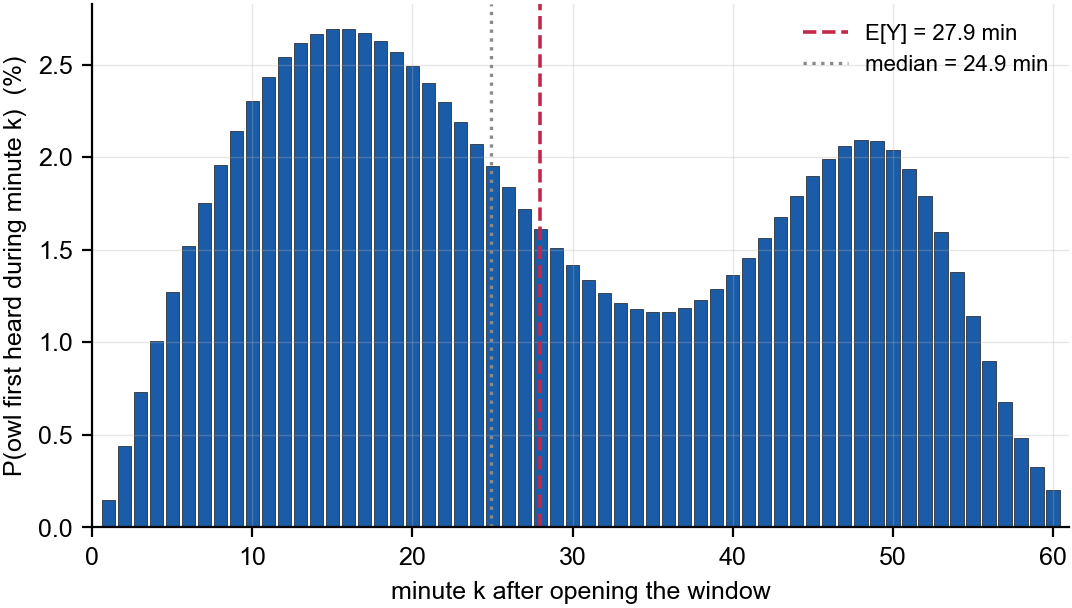

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(owl_minutes, 100 * owl_per_minute, width=0.85, color=ACCENT,
       edgecolor=INK, linewidth=0.25)
ax.axvline(owl_mean_exact * 60, color=ALT, linestyle="--", linewidth=1.3,
           label=f"E[Y] = {owl_mean_exact * 60:.1f} min")
ax.axvline(owl_quartiles[1] * 60, color=MUTED, linestyle=":", linewidth=1.2,
           label=f"median = {owl_quartiles[1] * 60:.1f} min")
ax.set_xlabel("minute k after opening the window")
ax.set_ylabel("P(owl first heard during minute k)  (%)")
ax.set_xlim(0, 61)
ax.legend(loc="upper right", frameon=False, fontsize=8)
owl_fig_hist = save_figure(fig, "task2_minutes")

In [10]:
results["task2"] = {
    "xi5": P.XI5, "xi7": P.XI7, "xi5_plus_xi7": P.XI5 + P.XI7,
    # The mass the delivered weights leave unassigned at y = 0.
    "xi_deficit": 1 - (P.XI5 + P.XI7),
    "xi6": owl_a, "xi8": owl_b,
    "w1": owl_w1, "w2": owl_w2,
    "w1_frac": "2/3", "w2_frac": "1/3",
    "survival_at_0_raw": P.XI5 + P.XI7,
    "survival_at_0": float(owl_survival(0.0)),
    "mass": owl_total_mass,
    "mean_h": owl_mean_exact, "mean_min": owl_mean_exact * 60,
    "mean_num_h": owl_mean_num,
    "mean_abs_err": abs(owl_mean_exact - owl_mean_num),
    "second_exact": owl_second_exact, "second_num": owl_second_num,
    "var_h2": owl_var_exact, "var_min2": owl_var_exact * 3600,
    "sd_h": math.sqrt(owl_var_exact), "sd_min": math.sqrt(owl_var_exact) * 60,
    "q1_h": owl_quartiles[0], "q1_min": owl_quartiles[0] * 60,
    "median_h": owl_quartiles[1], "median_min": owl_quartiles[1] * 60,
    "q3_h": owl_quartiles[2], "q3_min": owl_quartiles[2] * 60,
    "iqr_min": (owl_quartiles[2] - owl_quartiles[0]) * 60,
    "p_2_4": owl_p_2_4,
    "p_within_hour": owl_p_within_hour,
    "p_within_hour_pct": 100 * owl_p_within_hour,
    "peak_minute": int(owl_minutes[int(np.argmax(owl_per_minute))]),
    "peak_minute_pct": float(100 * owl_per_minute.max()),
    # The two leading minutes differ in the fourth decimal of a per cent, so
    # the prose reports them as a tie rather than naming a single winner.
    "peak_minute_2": int(owl_minutes[int(np.argsort(owl_per_minute)[-2])]),
    "peak_minute_2_pct": float(100 * np.sort(owl_per_minute)[-2]),
    "comp1_shape": 2, "comp2_shape": 8,
    "comp1_scale": owl_comp1_scale, "comp2_scale": owl_comp2_scale,
    "comp1_mean_min": owl_comp1_mean * 60, "comp2_mean_min": owl_comp2_mean * 60,
    "mode1_min": 60 * owl_mode1,
    "mode2_min": 60 * owl_mode2,
    "fig_pdf": owl_fig_pdf, "fig_hist": owl_fig_hist,
}
print(f"task2: {len(results['task2'])} results")

task2: 47 results


## Task 3 — bandwidth to failure of a pair of routers

With $\xi_9 = 0$ a single router carries an exponentially distributed volume
$S$ with mean $\theta$, and the standby pair delivers $T = S_1 + S_2$, which is
$\operatorname{Gamma}(2, \theta)$. The log-likelihood of an independent sample
$T_1,\dots,T_n$ is

$$\ell(\theta) = \sum_i \log T_i - 2n\log\theta - \frac{1}{\theta}\sum_i T_i ,$$

and setting $\ell'(\theta) = 0$ gives $\hat\theta = \bar T / 2$.

The cell below evaluates that closed form and then maximises $\ell$ numerically
as an independent check. It also computes the Fisher information
$I(\theta) = 2n/\theta^2$, whose inverse square root is the standard error, and
compares the observed coefficient of variation with the $1/\sqrt{2}$ that
$\operatorname{Gamma}(2, \theta)$ implies — a cheap goodness-of-fit look.

In [11]:
router_t = np.array(P.XI10, dtype=float)
router_n = router_t.size
router_total = router_t.sum()
theta_hat = router_total / (2 * router_n)


def router_loglik(theta):
    theta = np.asarray(theta, dtype=float)
    return (np.sum(np.log(router_t)) - 2 * router_n * np.log(theta)
            - router_total / theta)


# Numerical maximisation as an independent check on the closed form.
router_numeric = optimize.minimize_scalar(
    lambda th: -router_loglik(th), bracket=(theta_hat / 2, theta_hat * 2))

router_expected_t = 2 * theta_hat
router_fisher = 2 * router_n / theta_hat ** 2
router_se = 1 / math.sqrt(router_fisher)

router_cv_obs = router_t.std(ddof=1) / router_t.mean()
router_cv_model = 1 / math.sqrt(2)

print(f"sample     {', '.join(f'{v:g}' for v in router_t)}  (n = {router_n})")
print(f"theta_hat  closed form {theta_hat:.6f}   numeric {float(router_numeric.x):.6f}"
      f"   difference {abs(theta_hat - float(router_numeric.x)):.2e}")
print(f"E[T]       {router_expected_t:.2f} TB    standard error {router_se:.2f} TB")
print(f"CV         observed {router_cv_obs:.4f}   model {router_cv_model:.4f}")

sample     33, 29, 6, 37, 1  (n = 5)
theta_hat  closed form 10.600000   numeric 10.600000   difference 1.44e-07
E[T]       21.20 TB    standard error 3.35 TB
CV         observed 0.7782   model 0.7071


### Figure 4 — the log-likelihood and the fitted density

Panel (a) shows that $\ell$ has a single interior maximum, which is what makes
the estimate well defined. Panel (b) puts the fitted $\operatorname{Gamma}(2, \hat\theta)$
density against the five observations, drawn as ticks, so the reader can see
how little the sample constrains the fit.

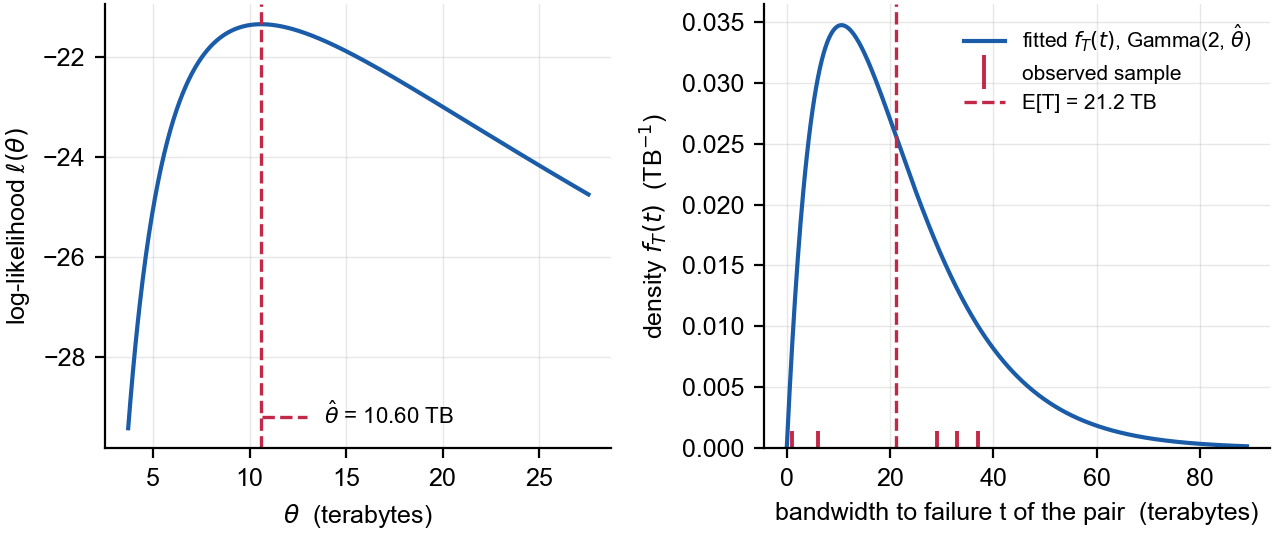

In [12]:
router_grid = np.linspace(theta_hat * 0.35, theta_hat * 2.6, 600)
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.9))

ax = axes[0]
ax.plot(router_grid, router_loglik(router_grid), color=ACCENT, linewidth=1.5)
ax.axvline(theta_hat, color=ALT, linestyle="--", linewidth=1.2,
           label=fr"$\hat\theta$ = {theta_hat:.2f} TB")
ax.set_xlabel(r"$\theta$  (terabytes)")
ax.set_ylabel(r"log-likelihood $\ell(\theta)$")
ax.legend(loc="lower center", frameon=False, fontsize=8)

ax = axes[1]
router_tt = np.linspace(0, max(router_t.max(), 4 * router_expected_t) * 1.05, 500)
ax.plot(router_tt, stats.gamma.pdf(router_tt, a=2, scale=theta_hat), color=ACCENT,
        linewidth=1.5, label=r"fitted $f_T(t)$, Gamma(2, $\hat\theta$)")
ax.plot(router_t, np.zeros_like(router_t), "|", color=ALT, markersize=12,
        markeredgewidth=1.4, label="observed sample")
ax.axvline(router_expected_t, color=ALT, linestyle="--", linewidth=1.2,
           label=f"E[T] = {router_expected_t:.1f} TB")
ax.set_xlabel("bandwidth to failure t of the pair  (terabytes)")
ax.set_ylabel(r"density $f_T(t)$  (TB$^{-1}$)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", frameon=False, fontsize=7.5)

fig.tight_layout()
router_fig = save_figure(fig, "task3_mle")

In [13]:
results["task3"] = {
    "n": router_n, "sample": ", ".join(f"{v:g}" for v in router_t),
    "total": router_total, "mean": router_t.mean(),
    "theta_hat": theta_hat,
    "theta_numeric": float(router_numeric.x),
    "theta_abs_err": abs(theta_hat - float(router_numeric.x)),
    "expected_t": router_expected_t,
    "se": router_se, "fisher": router_fisher,
    "ci_lo": theta_hat - 1.959964 * router_se,
    "ci_hi": theta_hat + 1.959964 * router_se,
    "cv_obs": router_cv_obs, "cv_model": router_cv_model,
    "sd_t": math.sqrt(2) * theta_hat,
    "fig": router_fig,
}
print(f"task3: {len(results['task3'])} results")

task3: 16 results


## Task 4 — hypothesis test on hammer weights

The population standard deviation $\sigma_0 = \xi_{12}$ is given, so the
correct test of $H_0: \mu = \mu_0$ against $H_1: \mu > \mu_0$ is the one-sided
**z-test**, not a t-test. The two are easy to confuse: the t-test is what you
use when $\sigma$ has to be estimated from the sample by $s$. Here it does not,
so the standard error is $\sigma_0/\sqrt{n}$ and the reference distribution is
the standard normal.

$$Z = \frac{\bar X - \mu_0}{\sigma_0/\sqrt{n}} \;\sim\; N(0, 1) \text{ under } H_0 .$$

The t-statistic is computed anyway, purely so the workbook can state what the
other reading would have given and show that the conclusion does not hinge on
the choice.

Two design quantities follow the test: the power at the observed mean, and the
difference $\delta$ that this sample size could detect with 80 % power. They
are what turn "fail to reject" into a statement about what the experiment was
capable of seeing.

In [14]:
hammer_x = np.array(P.XI14, dtype=float)
hammer_n = hammer_x.size
mu0, sigma0 = P.XI11, P.XI12
hammer_xbar = hammer_x.mean()
hammer_s = hammer_x.std(ddof=1)

hammer_se = sigma0 / math.sqrt(hammer_n)
hammer_z = (hammer_xbar - mu0) / hammer_se
hammer_alpha = 0.05
hammer_z_crit = stats.norm.ppf(1 - hammer_alpha)
hammer_p_value = float(stats.norm.sf(hammer_z))
hammer_crit_weight = mu0 + hammer_z_crit * hammer_se

hammer_t_stat = (hammer_xbar - mu0) / (hammer_s / math.sqrt(hammer_n))
hammer_t_crit = stats.t.ppf(1 - hammer_alpha, df=hammer_n - 1)
hammer_t_p = float(stats.t.sf(hammer_t_stat, df=hammer_n - 1))

# Power of the z-test at the observed mean, and the difference the design
# could detect with 80 % power.
hammer_power = float(stats.norm.sf(hammer_z_crit - (hammer_xbar - mu0) / hammer_se))
hammer_delta_80 = (hammer_z_crit + stats.norm.ppf(0.80)) * hammer_se
hammer_n_for_obs = ((hammer_z_crit + stats.norm.ppf(0.80)) * sigma0
                    / (hammer_xbar - mu0)) ** 2

print(f"xbar {hammer_xbar:.2f} g   mu0 {mu0:.0f} g   difference {hammer_xbar - mu0:+.2f} g")
print(f"z    {hammer_z:.4f}  vs critical {hammer_z_crit:.4f}   p = {hammer_p_value:.4f}")
print(f"t    {hammer_t_stat:.4f}  vs critical {hammer_t_crit:.4f}   p = {hammer_t_p:.4f}")
print(f"decision at alpha = {hammer_alpha:.2f}: "
      f"{'reject H0' if hammer_z > hammer_z_crit else 'fail to reject H0'}")
print(f"power at the observed mean {100 * hammer_power:.1f} %; "
      f"80 % power would need a shift of {hammer_delta_80:.1f} g "
      f"or n = {math.ceil(hammer_n_for_obs)}")

xbar 852.20 g   mu0 842 g   difference +10.20 g
z    0.5833  vs critical 1.6449   p = 0.2799
t    0.2567  vs critical 1.8331   p = 0.4016
decision at alpha = 0.05: fail to reject H0
power at the observed mean 14.4 %; 80 % power would need a shift of 43.5 g or n = 182


### Figure 5 — the test, drawn

The sampling density of $\bar X$ under $H_0$, with the 5 % rejection region
shaded and the observed mean marked. The picture is the argument: the observed
mean sits inside the region the null model comfortably produces.

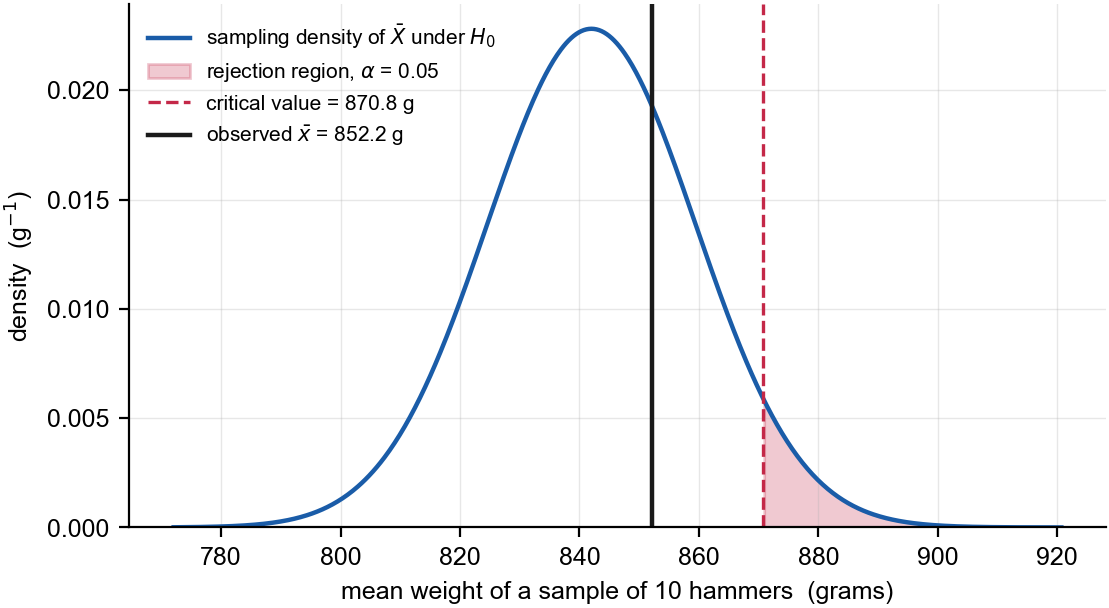

In [15]:
hammer_grid = np.linspace(mu0 - 4 * hammer_se, mu0 + 4.5 * hammer_se, 700)
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(hammer_grid, stats.norm.pdf(hammer_grid, mu0, hammer_se), color=ACCENT,
        linewidth=1.6, label=r"sampling density of $\bar{X}$ under $H_0$")
hammer_reject = hammer_grid >= hammer_crit_weight
ax.fill_between(hammer_grid[hammer_reject],
                stats.norm.pdf(hammer_grid[hammer_reject], mu0, hammer_se),
                color=ALT, alpha=0.25,
                label=fr"rejection region, $\alpha$ = {hammer_alpha:.2f}")
ax.axvline(hammer_crit_weight, color=ALT, linestyle="--", linewidth=1.2,
           label=f"critical value = {hammer_crit_weight:.1f} g")
ax.axvline(hammer_xbar, color=INK, linestyle="-", linewidth=1.6,
           label=fr"observed $\bar{{x}}$ = {hammer_xbar:.1f} g")
ax.set_xlabel("mean weight of a sample of 10 hammers  (grams)")
ax.set_ylabel(r"density  (g$^{-1}$)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", frameon=False, fontsize=7.5)
hammer_fig = save_figure(fig, "task4_test")

In [16]:
results["task4"] = {
    "n": hammer_n, "sample": ", ".join(f"{v:g}" for v in hammer_x),
    "mu0": mu0, "sigma0": sigma0,
    "xbar": hammer_xbar, "s": hammer_s, "se": hammer_se,
    "diff": hammer_xbar - mu0,
    "z": hammer_z, "z_crit": hammer_z_crit, "p_value": hammer_p_value,
    "crit_weight": hammer_crit_weight,
    "alpha": hammer_alpha, "alpha_pct": 100 * hammer_alpha,
    "t_stat": hammer_t_stat, "t_crit": hammer_t_crit, "t_p": hammer_t_p,
    "df": hammer_n - 1,
    "power_at_obs": hammer_power, "power_at_obs_pct": 100 * hammer_power,
    "beta_at_obs_pct": 100 * (1 - hammer_power),
    "delta_80": hammer_delta_80,
    "n_for_obs": math.ceil(hammer_n_for_obs),
    "var_ratio": (hammer_s / sigma0) ** 2,
    "fig": hammer_fig,
}
print(f"task4: {len(results['task4'])} results")

task4: 25 results


## Task 5 — OLS and ridge on a degree-10 polynomial

Eleven coefficients are fitted to a small sample whose $x$ values span two
orders of magnitude and whose $y$ values span thirteen. Two numerical points
dominate everything else here and are dealt with before any statistics.

**Rescaling.** Both axes are divided by their largest absolute value, so the
fit is done on dimensionless quantities. This matters twice: it cuts the
condition number of the design matrix by orders of magnitude, and it makes the
ridge penalty $\lambda$ meaningful at all — $\lambda$ trades against the
squared residual, so it has no scale-free interpretation until $x$ and $y$ are
dimensionless. Coefficients are mapped back to the original units at the end.

**Solving by SVD rather than the normal equations.** Forming and inverting
$X'X$ squares the condition number. Even after rescaling the design has a
condition number near $4\times 10^3$, so $X'X$ sits near $10^7$ and small
penalties lose all precision. The class below therefore reads the penalised
solution straight off the singular value decomposition, following Hastie,
Tibshirani and Friedman (2009, sec. 3.4.1), and centres the columns so that
the intercept is not penalised:

$$\beta(\lambda) = V \operatorname{diag}\!\left(\frac{d}{d^2 + \lambda}\right) U' y_c ,$$

which is stable for every $\lambda \ge 0$. Setting $\lambda = 0$ recovers OLS,
which is checked against NumPy's own least-squares solver further down.

The class also exposes the leverages (the diagonal of the hat matrix) so that
leave-one-out cross-validation can be evaluated in closed form, without
refitting the model $n$ times.

In [17]:
def poly_design(x_scaled: np.ndarray, degree: int) -> np.ndarray:
    return np.vander(x_scaled, degree + 1, increasing=True)


class Ridge:
    """Ridge regression with an unpenalised intercept, solved by SVD.

    Forming and inverting the Gram matrix X'X squares the condition number and
    is unusable here: even after rescaling x the design has condition number
    around 4e3, so X'X sits near 1e7 and small penalties lose all precision.
    Following Hastie, Tibshirani and Friedman (2009, sec. 3.4.1) the intercept
    is excluded from the penalty by centring the remaining columns, and the
    penalised solution is read straight off the singular value decomposition:

        beta(lambda) = V diag(d / (d^2 + lambda)) U' y_centred

    which is stable for every lambda >= 0.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.x_mean = X[:, 1:].mean(axis=0)
        self.y_mean = float(y.mean())
        self.Xc = X[:, 1:] - self.x_mean
        self.yc = y - self.y_mean
        self.U, self.d, self.Vt = np.linalg.svd(self.Xc, full_matrices=False)
        self.n = X.shape[0]

    def coefficients(self, lam: float) -> np.ndarray:
        """Return coefficients in the original basis, intercept first."""
        shrunk = self.d / (self.d ** 2 + lam)
        slope = matvec(self.Vt.T, shrunk * matvec(self.U.T, self.yc))
        intercept = self.y_mean - float(self.x_mean @ slope)
        return np.concatenate([[intercept], slope])

    def leverages(self, lam: float) -> np.ndarray:
        """Diagonal of the hat matrix, including the unpenalised intercept."""
        factors = self.d ** 2 / (self.d ** 2 + lam)
        return 1.0 / self.n + matvec(self.U ** 2, factors)

    def loo_mse(self, lam: float) -> float:
        """Leave-one-out mean squared error via the closed-form shortcut."""
        beta = self.coefficients(lam)
        residual = self.yc - matvec(self.Xc, beta[1:])
        return float(np.mean((residual / (1.0 - self.leverages(lam))) ** 2))

### Building the design and fitting OLS

`cond_raw` and `cond_scaled` are reported in the workbook to justify the
rescaling, and `ols_check` is the largest coefficient discrepancy between the
SVD route at $\lambda = 0$ and `numpy.linalg.lstsq` — an independent
confirmation that the class really does reduce to ordinary least squares.

In [18]:
poly_pairs = sorted(P.XI16)
poly_x = np.array([a for a, _ in poly_pairs], dtype=float)
poly_y = np.array([b for _, b in poly_pairs], dtype=float)
poly_n, poly_degree = poly_x.size, 10

poly_x_scale = np.abs(poly_x).max()
poly_y_scale = np.abs(poly_y).max()
poly_xs, poly_ys = poly_x / poly_x_scale, poly_y / poly_y_scale

poly_X_raw = poly_design(poly_x, poly_degree)
poly_X = poly_design(poly_xs, poly_degree)
poly_cond_raw = float(np.linalg.cond(poly_X_raw))
poly_cond_scaled = float(np.linalg.cond(poly_X))

poly_fit = Ridge(poly_X, poly_ys)

beta_ols = poly_fit.coefficients(0.0)
poly_resid_ols = poly_ys - matvec(poly_X, beta_ols)
poly_rmse_ols = float(np.sqrt(np.mean(poly_resid_ols ** 2)))

# Independent check that the SVD route at lambda = 0 is ordinary least
# squares: compare against NumPy's own least-squares solver.
beta_lstsq = np.linalg.lstsq(poly_X, poly_ys, rcond=None)[0]
poly_ols_check = float(np.abs(beta_ols - beta_lstsq).max())

print(f"n = {poly_n} points, degree {poly_degree}, {poly_degree + 1} coefficients")
print(f"condition number  raw {poly_cond_raw:.3e}   scaled {poly_cond_scaled:.3e}"
      f"   ratio {poly_cond_raw / poly_cond_scaled:.3e}")
print(f"SVD vs lstsq at lambda = 0: max coefficient difference {poly_ols_check:.2e}")

n = 22 points, degree 10, 11 coefficients
condition number  raw 1.016e+13   scaled 3.738e+03   ratio 2.718e+09
SVD vs lstsq at lambda = 0: max coefficient difference 1.87e-13


### Choosing the penalty by leave-one-out cross-validation

The criterion is evaluated on a logarithmic grid from $10^{-12}$ to $10^{2}$
for the figure, then refined inside the bracketing grid cell. The refinement
is not cosmetic: at 20 points per decade the grid spacing is 12 %, so reading
$\lambda^*$ off a grid node would fix its second significant digit by accident.

The criterion is also shallow near its minimum, so the range of penalties
scoring within 1 % of the best is reported alongside $\lambda^*$ rather than
implying that the minimiser is sharply determined.

In [19]:
poly_lambdas = np.logspace(-12, 2, 281)
poly_loo = np.array([poly_fit.loo_mse(lam) for lam in poly_lambdas])
poly_coarse = int(np.argmin(poly_loo))

poly_lo = math.log10(poly_lambdas[max(poly_coarse - 1, 0)])
poly_hi = math.log10(poly_lambdas[min(poly_coarse + 1, poly_lambdas.size - 1)])
lam_star = float(10 ** optimize.minimize_scalar(
    lambda t: poly_fit.loo_mse(10 ** t), bounds=(poly_lo, poly_hi),
    method="bounded", options={"xatol": 1e-6}).x)

poly_loo_star = poly_fit.loo_mse(lam_star)
poly_band = np.logspace(poly_lo - 1, poly_hi + 1, 2001)
poly_inside = poly_band[np.array([poly_fit.loo_mse(l) for l in poly_band])
                        <= poly_loo_star * 1.01]
lam_band_lo, lam_band_hi = float(poly_inside.min()), float(poly_inside.max())

print(f"lambda*        {lam_star:.4e}")
print(f"within 1 % of the best score: [{lam_band_lo:.2e}, {lam_band_hi:.2e}]")

lambda*        4.2258e-04
within 1 % of the best score: [3.02e-04, 6.00e-04]


### The three fits, and what they cost

Three penalties are compared: $\lambda = 0$ (OLS), the cross-validated
$\lambda^*$, and a deliberately heavy $\lambda = 10^{-2}$ that shows what the
trade-off looks like when shrinkage is pushed too far.

Least squares on these data is dominated by the largest $|y|$, so a global
RMSE says almost nothing about the small-$|x|$ region where $|y|$ stays below
$2\times 10^9$. `small_rel_err` measures the worst relative error over exactly
that region, and it is the number the workbook uses to argue that neither
estimate should be trusted there.

In [20]:
beta_ridge = poly_fit.coefficients(lam_star)
poly_resid_ridge = poly_ys - matvec(poly_X, beta_ridge)
poly_rmse_ridge = float(np.sqrt(np.mean(poly_resid_ridge ** 2)))

# A deliberately heavy penalty, to show what the trade-off looks like.
lam_heavy = 1e-2
beta_heavy = poly_fit.coefficients(lam_heavy)
poly_rmse_heavy = float(np.sqrt(np.mean((poly_ys - matvec(poly_X, beta_heavy)) ** 2)))

poly_small = np.abs(poly_x) <= 7


def small_rel_err(beta):
    fitted = poly_y_scale * matvec(poly_X[poly_small], beta)
    return float(np.max(np.abs((fitted - poly_y[poly_small]) / poly_y[poly_small])))


def to_original(beta_scaled: np.ndarray) -> np.ndarray:
    """Map coefficients of the scaled fit back to the original x and y."""
    return beta_scaled * poly_y_scale / poly_x_scale ** np.arange(poly_degree + 1)


alpha_ols = to_original(beta_ols)
alpha_ridge = to_original(beta_ridge)
alpha_heavy = to_original(beta_heavy)

print(f"RMSE (original units)  OLS {poly_rmse_ols * poly_y_scale:.4e}"
      f"   ridge {poly_rmse_ridge * poly_y_scale:.4e}"
      f"   heavy {poly_rmse_heavy * poly_y_scale:.4e}")
print(f"coefficient norm       OLS {np.linalg.norm(beta_ols[1:]):.6f}"
      f"   ridge {np.linalg.norm(beta_ridge[1:]):.6f}")
print(f"worst relative error on the {int(poly_small.sum())} points with |x| <= 7:"
      f"  OLS {small_rel_err(beta_ols):.3f}   ridge {small_rel_err(beta_ridge):.3f}")

RMSE (original units)  OLS 1.6263e+11   ridge 2.9579e+11   heavy 5.5379e+11
coefficient norm       OLS 6.625457   ridge 1.014332
worst relative error on the 8 points with |x| <= 7:  OLS 193524942145.487   ridge 7883565308.525


### Figure 6 — three panels

Panel (a) is the full range, on which the two fits are indistinguishable from
the data — which is exactly why panel (b) is needed. Panel (b) zooms into
$|x| \le 7$, where both fits are worthless. Panel (c) shows how the penalty
was chosen.

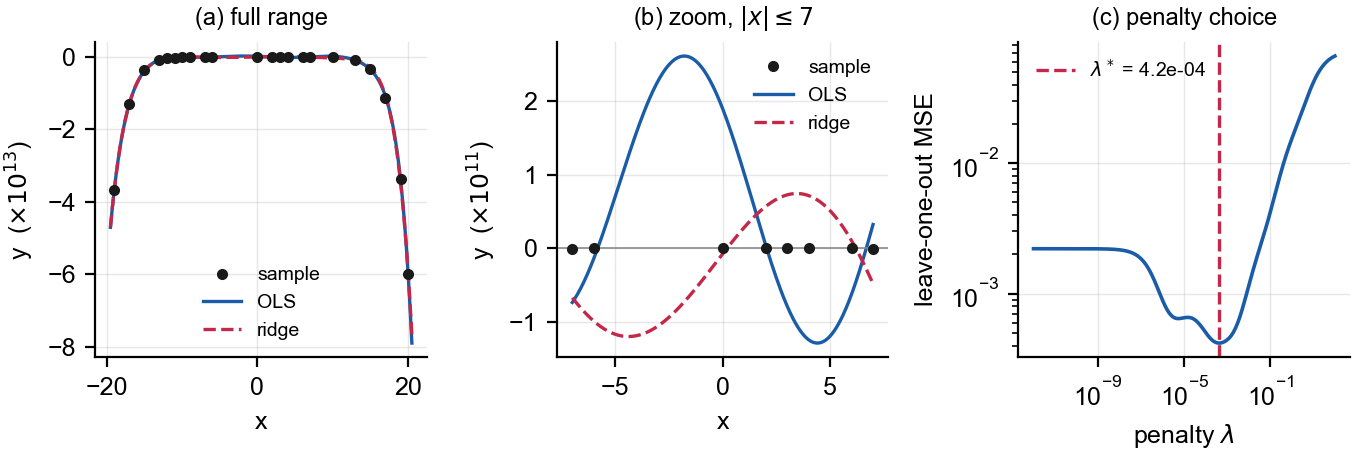

In [21]:
poly_grid = np.linspace(poly_x.min() - 0.5, poly_x.max() + 0.5, 800)
poly_Xg = poly_design(poly_grid / poly_x_scale, poly_degree)
poly_fit_ols = poly_y_scale * matvec(poly_Xg, beta_ols)
poly_fit_ridge = poly_y_scale * matvec(poly_Xg, beta_ridge)

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.5))

# (a) Full range. On this scale both estimates are indistinguishable from
# the data, which is the entire reason panel (b) is needed.
ax = axes[0]
ax.plot(poly_x, poly_y / 1e13, "o", color=INK, markersize=3.0,
        label="sample", zorder=5)
ax.plot(poly_grid, poly_fit_ols / 1e13, color=ACCENT, linewidth=1.2, label="OLS")
ax.plot(poly_grid, poly_fit_ridge / 1e13, color=ALT, linewidth=1.2, linestyle="--",
        label="ridge")
ax.set_xlabel("x")
ax.set_ylabel(r"y  ($\times 10^{13}$)")
ax.set_title("(a) full range", fontsize=8.5)
ax.legend(loc="lower center", frameon=False, fontsize=7)

# (b) The small-|x| region, where both fits are worthless.
ax = axes[1]
poly_zoom = np.abs(poly_grid) <= 7
ax.plot(poly_x[poly_small], poly_y[poly_small] / 1e11, "o", color=INK,
        markersize=3.0, label="sample", zorder=5)
ax.plot(poly_grid[poly_zoom], poly_fit_ols[poly_zoom] / 1e11, color=ACCENT,
        linewidth=1.2, label="OLS")
ax.plot(poly_grid[poly_zoom], poly_fit_ridge[poly_zoom] / 1e11, color=ALT,
        linewidth=1.2, linestyle="--", label="ridge")
ax.axhline(0, color=MUTED, linewidth=0.6)
ax.set_xlabel("x")
ax.set_ylabel(r"y  ($\times 10^{11}$)")
ax.set_title(r"(b) zoom, $|x| \leq 7$", fontsize=8.5)
ax.legend(loc="upper right", frameon=False, fontsize=7)

# (c) How the penalty was chosen.
ax = axes[2]
ax.loglog(poly_lambdas, poly_loo, color=ACCENT, linewidth=1.3)
ax.axvline(lam_star, color=ALT, linestyle="--", linewidth=1.2,
           label=fr"$\lambda^*$ = {lam_star:.1e}")
ax.set_xlabel(r"penalty $\lambda$")
ax.set_ylabel("leave-one-out MSE")
ax.set_title("(c) penalty choice", fontsize=8.5)
ax.legend(loc="upper left", frameon=False, fontsize=7)

fig.tight_layout()
poly_fig = save_figure(fig, "task5_ridge")

### The coordinate table for Appendix A

The generator prints the pairs to two decimals, so `.2f` reproduces them
verbatim. Building the table here rather than typing it keeps it from drifting
if the parameter set is ever regenerated.

In [22]:
def pairs_table(pairs: list) -> str:
    """Render the Task 5 coordinate pairs as Markdown rows, two pairs per row."""
    half = (len(pairs) + 1) // 2
    left, right = pairs[:half], pairs[half:]
    rows = []
    for index in range(half):
        cells = []
        for column in (left, right):
            if index < len(column):
                x, y = column[index]
                cells += [f"${x:.0f}$", f"${y:.2f}$"]
            else:
                cells += ["", ""]
        rows.append("| " + " | ".join(cells) + " |")
    return "\n".join(rows)


def fmt_vector(vec: np.ndarray) -> str:
    return ", ".join(f"{v:.4g}" for v in vec)

In [23]:
results["task5"] = {
    "n": poly_n, "degree": poly_degree, "n_params": poly_degree + 1,
    "x_min": poly_x.min(), "x_max": poly_x.max(),
    "y_min": poly_y.min(), "y_max": poly_y.max(),
    "x_scale": poly_x_scale, "y_scale": poly_y_scale,
    "cond_raw": poly_cond_raw, "cond_scaled": poly_cond_scaled,
    "cond_ratio": poly_cond_raw / poly_cond_scaled,
    "lam_star": lam_star, "lam_heavy": lam_heavy,
    "lam_band_lo": lam_band_lo, "lam_band_hi": lam_band_hi,
    "pairs_rows": pairs_table(poly_pairs),
    "rmse_ols": poly_rmse_ols * poly_y_scale,
    "rmse_ridge": poly_rmse_ridge * poly_y_scale,
    "rmse_heavy": poly_rmse_heavy * poly_y_scale,
    "rmse_ols_rel": poly_rmse_ols, "rmse_ridge_rel": poly_rmse_ridge,
    "rmse_heavy_rel": poly_rmse_heavy,
    "norm_ols": float(np.linalg.norm(beta_ols[1:])),
    "norm_ridge": float(np.linalg.norm(beta_ridge[1:])),
    "norm_heavy": float(np.linalg.norm(beta_heavy[1:])),
    "norm_shrink_pct": 100 * (1 - float(np.linalg.norm(beta_ridge[1:]))
                              / float(np.linalg.norm(beta_ols[1:]))),
    "alpha_ols": fmt_vector(alpha_ols), "alpha_ridge": fmt_vector(alpha_ridge),
    "alpha_heavy": fmt_vector(alpha_heavy),
    "a0_ols": alpha_ols[0], "a0_ridge": alpha_ridge[0],
    "a10_ols": alpha_ols[10], "a10_ridge": alpha_ridge[10],
    "y_at_zero": float(poly_y[poly_x == 0][0]) if np.any(poly_x == 0) else float("nan"),
    "n_small": int(poly_small.sum()),
    "small_rel_ols": small_rel_err(beta_ols),
    "small_rel_ridge": small_rel_err(beta_ridge),
    "ols_check": poly_ols_check,
    "fig": poly_fig,
}
print(f"task5: {len(results['task5'])} results")

task5: 40 results


## Task 6 — Bayesian estimate of a gamma rate

Ten observations $x_1,\dots,x_{10}$ are drawn from a gamma density with known
shape $\alpha = 3$ and unknown rate $\theta$, and $\theta$ carries a gamma
prior. The gamma family is conjugate to itself in this setting, so the
posterior is again gamma with

$$\text{shape} = \xi_{17} + \alpha n , \qquad \text{rate} = \frac{1}{\xi_{18}} + \sum_i x_i .$$

**The convention trap.** Hogg, McKean and Craig write the gamma density with
$\beta$ as a **scale**, and the workbook follows them without exception. Read
consistently, the prior rate is therefore $1/\xi_{18}$, not $\xi_{18}$. A
reader using the other convention would get a visibly different posterior, so
the alternative reading is computed as well and reported, with the size of the
discrepancy, rather than left as a silent assumption.

The maximum likelihood estimate $\alpha/\bar x$ is computed for comparison: it
is what the data alone would say, and its distance from the posterior mean is
the visible contribution of the prior.

In [24]:
bayes_n, bayes_alpha = P.TASK6_N, P.TASK6_ALPHA
prior_shape, prior_beta = P.XI17, P.XI18
bayes_xbar = P.XI19
bayes_total = bayes_n * bayes_xbar

# Hogg, McKean and Craig write the gamma density with beta as a scale.
# Read consistently, the prior rate is 1/xi18.
post_shape = prior_shape + bayes_alpha * bayes_n
post_rate = 1.0 / prior_beta + bayes_total
post_mean = post_shape / post_rate
post_mode = (post_shape - 1) / post_rate

# The alternative reading, in which xi18 is a rate, is reported so that a
# reader who uses the other convention can locate the difference at once.
alt_rate = prior_beta + bayes_total
alt_mean = post_shape / alt_rate
alt_mode = (post_shape - 1) / alt_rate

prior_mean = prior_shape * prior_beta
bayes_mle = bayes_alpha / bayes_xbar

cred_lo = stats.gamma.ppf(0.025, a=post_shape, scale=1 / post_rate)
cred_hi = stats.gamma.ppf(0.975, a=post_shape, scale=1 / post_rate)

print(f"prior      Gamma(shape {prior_shape:.0f}, scale {prior_beta:.0f})"
      f"  ->  rate {1 / prior_beta:.6f}, mean {prior_mean:.0f}")
print(f"data       n = {bayes_n}, xbar = {bayes_xbar}, sum = {bayes_total:.0f}")
print(f"posterior  Gamma(shape {post_shape:.0f}, rate {post_rate:.1f})")
print(f"           mean {post_mean:.6f}   mode {post_mode:.6f}   MLE {bayes_mle:.6f}")
print(f"           95 % credible interval [{cred_lo:.6f}, {cred_hi:.6f}]")
print(f"alternative reading (xi18 as a rate): mean {alt_mean:.6f}"
      f"   differs by {100 * abs(alt_mean - post_mean) / post_mean:.3f} %")
print(f"the prior contributes {100 * (1 / prior_beta) / post_rate:.4f} % of the posterior rate")

prior      Gamma(shape 23, scale 63)  ->  rate 0.015873, mean 1449
data       n = 10, xbar = 95.48, sum = 955
posterior  Gamma(shape 53, rate 954.8)
           mean 0.055508   mode 0.054461   MLE 0.031420
           95 % credible interval [0.041579, 0.071418]
alternative reading (xi18 as a rate): mean 0.052073   differs by 6.188 %
the prior contributes 0.0017 % of the posterior rate


### Figure 7 — prior and posterior

Two panels rather than one, because they cannot share an axis: the prior is
spread over hundreds of units while the posterior is concentrated near
$5\times 10^{-3}$. That gap is the point — ten observations move the estimate
by five orders of magnitude, so the prior is almost irrelevant here.

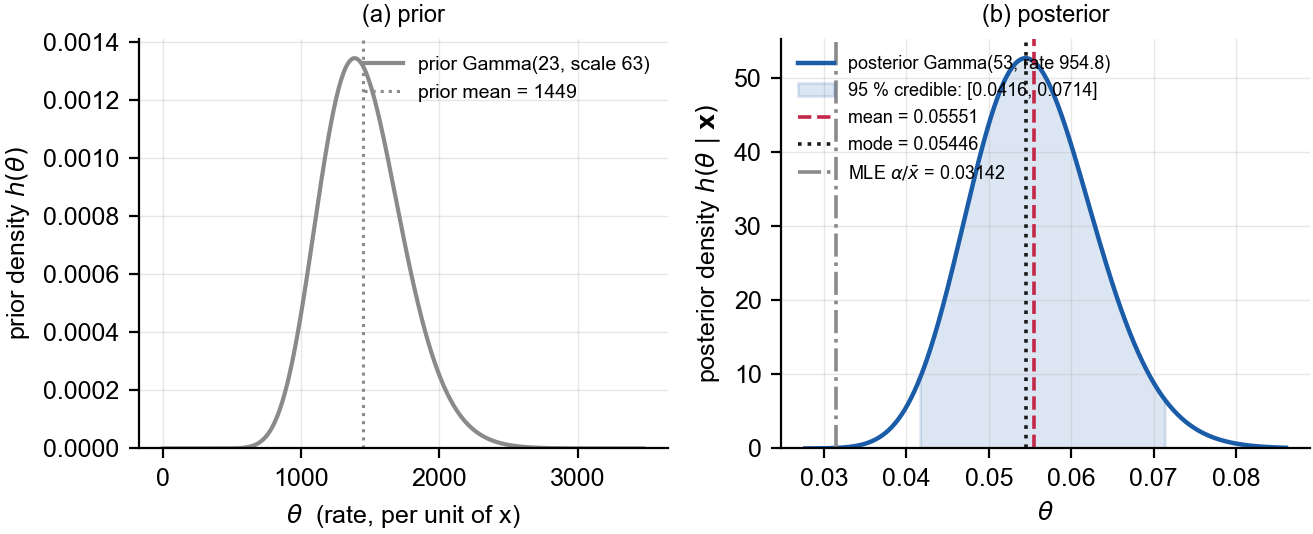

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.9))

ax = axes[0]
bayes_grid = np.linspace(0, prior_mean * 2.4, 600)
ax.plot(bayes_grid, stats.gamma.pdf(bayes_grid, a=prior_shape, scale=prior_beta),
        color=MUTED, linewidth=1.5,
        label=fr"prior Gamma({prior_shape:.0f}, scale {prior_beta:.0f})")
ax.axvline(prior_mean, color=MUTED, linestyle=":", linewidth=1.1,
           label=f"prior mean = {prior_mean:.0f}")
ax.set_xlabel(r"$\theta$  (rate, per unit of x)")
ax.set_ylabel(r"prior density $h(\theta)$")
ax.set_title("(a) prior", fontsize=8.5)
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", frameon=False, fontsize=7)

ax = axes[1]
bayes_grid = np.linspace(post_mean * 0.5, post_mean * 1.55, 600)
bayes_density = stats.gamma.pdf(bayes_grid, a=post_shape, scale=1 / post_rate)
ax.plot(bayes_grid, bayes_density, color=ACCENT, linewidth=1.6,
        label=fr"posterior Gamma({post_shape:.0f}, rate {post_rate:.1f})")
bayes_band = (bayes_grid >= cred_lo) & (bayes_grid <= cred_hi)
ax.fill_between(bayes_grid[bayes_band], bayes_density[bayes_band], color=ACCENT,
                alpha=0.15, label=f"95 % credible: [{cred_lo:.4f}, {cred_hi:.4f}]")
ax.axvline(post_mean, color=ALT, linestyle="--", linewidth=1.3,
           label=f"mean = {post_mean:.5f}")
ax.axvline(post_mode, color=INK, linestyle=":", linewidth=1.3,
           label=f"mode = {post_mode:.5f}")
ax.axvline(bayes_mle, color=MUTED, linestyle="-.", linewidth=1.3,
           label=fr"MLE $\alpha/\bar{{x}}$ = {bayes_mle:.5f}")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"posterior density $h(\theta \mid \mathbf{x})$")
ax.set_title("(b) posterior", fontsize=8.5)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", frameon=False, fontsize=6.5)

fig.tight_layout()
bayes_fig = save_figure(fig, "task6_posterior")

In [26]:
results["task6"] = {
    "n": bayes_n, "alpha_lik": bayes_alpha,
    "prior_shape": prior_shape, "prior_beta": prior_beta,
    "prior_rate": 1 / prior_beta, "prior_mean": prior_mean,
    "xbar": bayes_xbar, "total": bayes_total,
    "post_shape": post_shape, "post_rate": post_rate,
    "post_scale": 1 / post_rate,
    "post_mean": post_mean, "post_mode": post_mode,
    "post_sd": math.sqrt(post_shape) / post_rate,
    "alt_rate": alt_rate, "alt_mean": alt_mean, "alt_mode": alt_mode,
    "alt_mean_diff_pct": 100 * abs(alt_mean - post_mean) / post_mean,
    "mle": bayes_mle,
    "cred_lo": float(cred_lo), "cred_hi": float(cred_hi),
    "prior_weight_pct": 100 * (1 / prior_beta) / post_rate,
    "fig": bayes_fig,
}
print(f"task6: {len(results['task6'])} results")

task6: 23 results


## Output

The personal parameters are recorded alongside the six tasks so that Appendix A
and the title page draw their values from the same file as everything else.
The result is flattened to dotted keys and written to `build/results.json`,
which is the only interface between this notebook and the document.

In [27]:
results["meta"] = {
    "signature": P.SIGNATURE,
    "signature_short": P.SIGNATURE[:8],
    "xi1": P.XI1, "xi2": P.XI2, "xi4": P.XI4, "xi5": P.XI5, "xi6": P.XI6,
    "xi7": P.XI7, "xi8": P.XI8, "xi9": P.XI9,
    "xi10": ", ".join(f"{v:g}" for v in P.XI10),
    "xi11": P.XI11, "xi12": P.XI12, "xi13": P.XI13,
    "xi14": ", ".join(f"{v:g}" for v in P.XI14),
    "xi15": P.XI15,
    "xi16_n": len(P.XI16),
    "xi17": P.XI17, "xi18": P.XI18, "xi19": P.XI19,
}

BUILDDIR.mkdir(parents=True, exist_ok=True)
flat = flatten(results)
out = BUILDDIR / "results.json"
out.write_text(json.dumps(flat, indent=2, sort_keys=True, default=float),
               encoding="utf-8")

print(f"wrote {out.relative_to(HERE)} with {len(flat)} keys")
print(f"wrote {len(list(FIGDIR.glob('*.png')))} figures to figures/")

wrote build/results.json with 179 keys
wrote 7 figures to figures/
